In [18]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

import os
from dotenv import load_dotenv
from typing import TypedDict, Literal
import math

In [19]:
class QuadraticEqn(TypedDict):
    a : int
    b : int 
    c : int
    d : int
    roots : str
    result : str
    eqn : str

In [20]:
# To display Equation 

def display_eqn(state:QuadraticEqn)->dict:
    a=state['a']
    b=state['b']
    c=state['c']
    roots = f"""
        {a}x^2  {b}x  {c} = 0
    """
    return {'roots':roots}

In [21]:
# Calculate d

def calc_d(state:QuadraticEqn)->dict:
    a=state['a']
    b=state['b']
    c=state['c']


    d= b**2-4*a*c

    return {'d':d}

In [22]:
def check_d(state:QuadraticEqn)->Literal["real_root","img_root","single_root"]:
    if state['d'] >0:
        return "real_root"
    elif state['d']<0:
        return "img_root"
    else:
        return "single_root"
        

In [23]:
def real_root(state:QuadraticEqn)->dict:
    root1 = (- state['b'] + math.sqrt(state['d']))/(2*state['a'])
    root2 = (- state['b'] - math.sqrt(state['d']))/(2*state['a'])
    res = f"The roots are {root1} {root2}"
    return {'result':res}

In [24]:
def single_root(state:QuadraticEqn)->dict:
    res = f"The single root is {-state['b']/(2*state['a'])}"
    return {'result':res}

In [25]:
def img_root(state:QuadraticEqn)->dict:
    return {'result':"No real roots"}

In [26]:
graph=StateGraph(QuadraticEqn)

In [27]:
# Adding the nodes:

graph.add_node('display_eqn',display_eqn)
graph.add_node('calc_d',calc_d)
graph.add_node('img_root',img_root)
graph.add_node('real_root',real_root)
graph.add_node('single_root',single_root)

In [28]:
# Adding the edges

graph.add_edge(START,'display_eqn')
graph.add_edge('display_eqn','calc_d')
graph.add_conditional_edges('calc_d',check_d)
graph.add_edge('real_root',END)
graph.add_edge('img_root',END)
graph.add_edge('single_root',END)

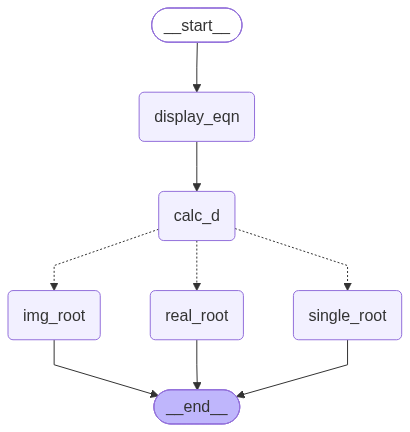

In [29]:
workflow=graph.compile()
display(Image(workflow.get_graph().draw_mermaid_png()))

In [30]:
result = workflow.invoke({'a':1,'b':-7,'c':12})
print(result)

{'a': 1, 'b': -7, 'c': 12, 'd': 1, 'roots': '\n        1x^2  -7x  12 = 0\n    ', 'result': 'The roots are 4.0 3.0'}
